# 3-D Seismic Data Loading Exercise

***

## <span style="color:blue">Load 3-D seismic data in SEG-Y format</span>

Befriko Murdianto, Apr 2025<br>
Reservoir Geophysics Graduate Program<br>
University of Indonesia

***

Here we'll load seismic data into python using <a href=https://github.com/equinor/segyio>segyio</a>.

In [1]:
!pip install segyio
import segyio
import numpy as np

#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)
#with segyio.open('/content/drive/My Drive/3Dseismic.sgy', ignore_geometry=True) as f;
with segyio.open('C:/Users/befriko.murdianto/OneDrive/Desktop/Documents/UI Lecture/Data/3Dseismic.sgy', ignore_geometry=True) as f:
    # Get basic attributes
    n_traces = f.tracecount
    sample_rate = segyio.tools.dt(f) / 1000
    n_samples = f.samples.size
    twt = f.samples
    data = f.trace.raw[:]  # Get all data into memory (could cause on big files)

f'N Traces: {n_traces}, N Samples: {n_samples}, Sample rate: {sample_rate}ms, Trace length: {max(twt)}'

'N Traces: 9639, N Samples: 151, Sample rate: 2.0ms, Trace length: 300.0'

Inline range: 1-119, crossline range: 1-81 (info from header) and reshape 2-D matrix into 3-D.

In [2]:
n_iline = 119; n_xline = 81
select = np.reshape(data, (n_iline,n_xline,n_samples))
print("data size is", len(select), "rows by", len(select[0]), "columns")

data size is 119 rows by 81 columns


Create coordinate grids from 1-D arrays using meshgrid.

In [3]:
iline = np.linspace(1, n_iline, 1); xline = np.linspace(1, n_xline, 1); time = np.linspace(800, twt+800, n_samples)
x, y, z = np.meshgrid(iline,xline,time)

Creating intersecting planes in matplotlib is complicated, I just copy and paste from the <a href=https://matplotlib.org/stable/gallery/mplot3d/intersecting_planes.html#sphx-glr-gallery-mplot3d-intersecting-planes-py>matplotlib example</a>.

In [29]:
import matplotlib.pyplot as plt

def plot_quadrants(ax, array, fixed_coord, cmap):
    """For a given 3d *array* plot a plane with *fixed_coord*, using four quadrants."""
    nx, ny, nz = array.shape
    index = {
        'x': (nx // 2, slice(None), slice(None)),
        'y': (slice(None), ny // 2, slice(None)),
        'z': (slice(None), slice(None), nz // 2),
    }[fixed_coord]
    plane_data = array[index]

    n0, n1 = plane_data.shape
    quadrants = [
        plane_data[:n0 // 2, :n1 // 2],
        plane_data[:n0 // 2, n1 // 2:],
        plane_data[n0 // 2:, :n1 // 2],
        plane_data[n0 // 2:, n1 // 2:]
    ]

    min_val = array.min()
    max_val = array.max()

    cmap = plt.get_cmap(cmap)

    for i, quadrant in enumerate(quadrants):
        facecolors = cmap((quadrant - min_val) / (max_val - min_val))
        if fixed_coord == 'x':
            Y, Z = np.mgrid[0:ny // 2, 0:nz // 2]
            X = nx // 2 * np.ones_like(Y)
            Y_offset = (i // 2) * ny // 2
            Z_offset = (i % 2) * nz // 2
            ax.plot_surface(X, Y + Y_offset, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False)
        elif fixed_coord == 'y':
            X, Z = np.mgrid[0:nx // 2, 0:nz // 2]
            Y = ny // 2 * np.ones_like(X)
            X_offset = (i // 2) * nx // 2
            Z_offset = (i % 2) * nz // 2
            ax.plot_surface(X + X_offset, Y, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False)
        elif fixed_coord == 'z':
            X, Y = np.mgrid[0:nx // 2, 0:ny // 2]
            Z = nz // 2 * np.ones_like(X)
            X_offset = (i // 2) * nx // 2
            Y_offset = (i % 2) * ny // 2
            ax.plot_surface(X + X_offset, Y + Y_offset, Z, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False)


def figure_3D_array_slices(array, cmap=None):
    """Plot a 3d array using three intersecting centered planes."""
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(array.shape)
    plot_quadrants(ax, array, 'x', cmap=cmap)
    plot_quadrants(ax, array, 'y', cmap=cmap)
    plot_quadrants(ax, array, 'z', cmap=cmap)
    ax.set_zlim(ax.get_zlim()[::-1])
    ax.set_xlabel(r'Inline')
    ax.set_ylabel(r'Crossline')
    fig.suptitle('3-D Seismic') 
    return fig, ax

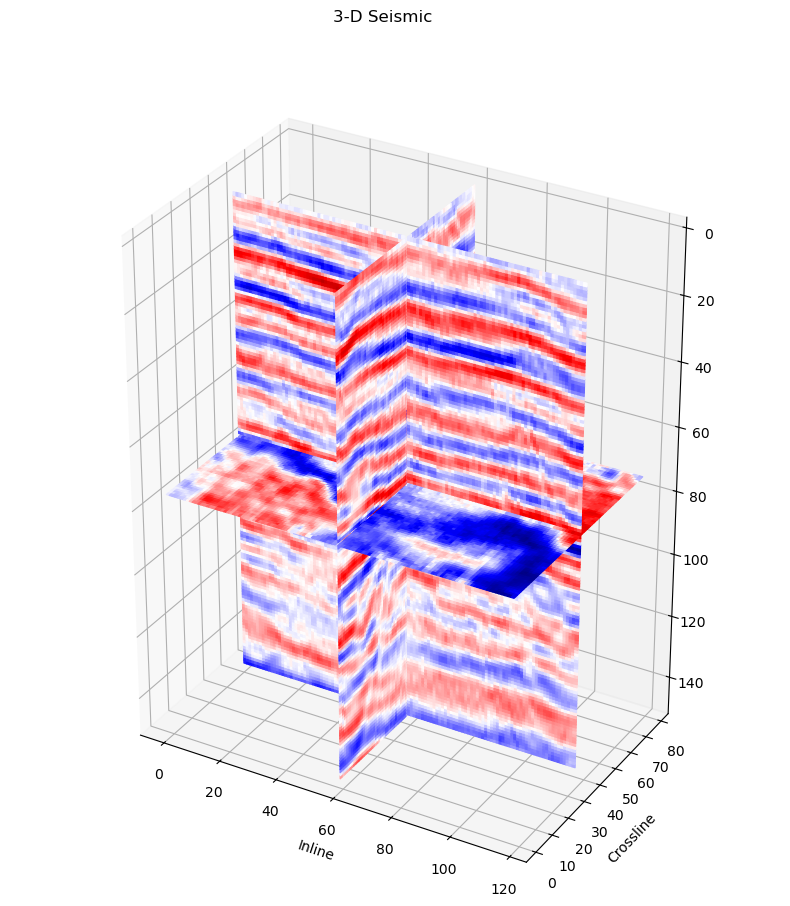

In [30]:
figure_3D_array_slices(select, cmap='seismic')
plt.show()